# Spiking Autoencoder for MNIST Reconstruction

This notebook implements a **spiking autoencoder** using Spiking Neural Networks (SNNs) to reconstruct MNIST digit images from spike-based representations.

---

## 🎯 Objective

- Encode static images into spike trains using **rate coding**
- Learn a compressed representation using spiking neurons
- Reconstruct the original image from spike activity

---

## 🧠 Key Idea

In spiking neural networks, information is represented through **spike timing or firing rate**.  
Here, we use **rate coding**, where pixel intensity is translated into spike frequency.

The decoder reconstructs the image by **aggregating spike activity over time**, showing that spike-based representations can preserve visual information.

---

## ⚠️ Note

This is a proof-of-concept demonstrating that SNNs can perform **representation learning and reconstruction**, similar to traditional autoencoders.

In [5]:
import torch
import torch.nn as nn
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
from snntorch import spikegen
import matplotlib.pyplot as plt

from core.models import SpikingAutoencoder

device = "cuda" if torch.cuda.is_available() else "cpu"
print("Using device:", device)


Using device: cpu


In [6]:
# Load MNIST dataset

transform = transforms.ToTensor()

train_ds = datasets.MNIST("./data", train=True, download=True, transform=transform)
test_ds  = datasets.MNIST("./data", train=False, download=True, transform=transform)

train_loader = DataLoader(train_ds, batch_size=128, shuffle=True)
test_loader  = DataLoader(test_ds, batch_size=128, shuffle=False)

print("Training samples:", len(train_ds))


Training samples: 60000


In [7]:
# Create the spiking autoencoder

model = SpikingAutoencoder().to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
loss_fn = nn.MSELoss()

num_steps = 25   # number of spike simulation steps
epochs = 5


In [8]:
# Train the spiking autoencoder

loss_history = []

for epoch in range(epochs):
    total_loss = 0
    
    for x, _ in train_loader:
        # Flatten image: (B, 1, 28, 28) -> (B, 784)
        x = x.view(-1, 784).to(device)

        # Convert image to spike trains using Poisson rate coding
        spk_in = spikegen.rate(x, num_steps=num_steps)

        # Forward pass through spiking network
        spk_out = model(spk_in)

        # Reconstruct by averaging spikes over time
        recon = spk_out.mean(0)

        # Reconstruction loss
        loss = loss_fn(recon, x)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    avg_loss = total_loss / len(train_loader)
    loss_history.append(avg_loss)
    print(f"Epoch {epoch+1}, Loss = {avg_loss:.4f}")


Epoch 1, Loss = 0.0147
Epoch 2, Loss = 0.0039
Epoch 3, Loss = 0.0027
Epoch 4, Loss = 0.0023
Epoch 5, Loss = 0.0020


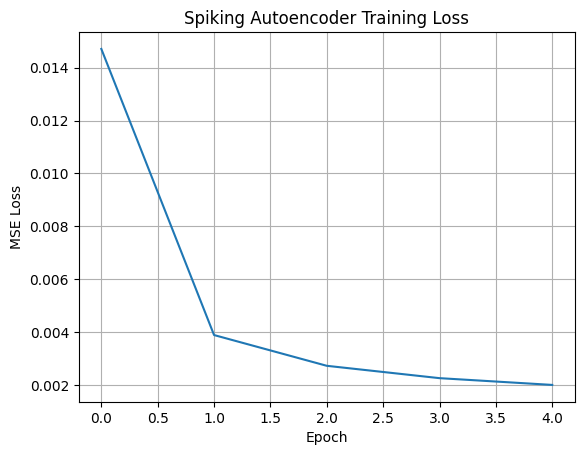

In [9]:
plt.plot(loss_history)
plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.title("Spiking Autoencoder Training Loss")
plt.grid(True)
plt.show()


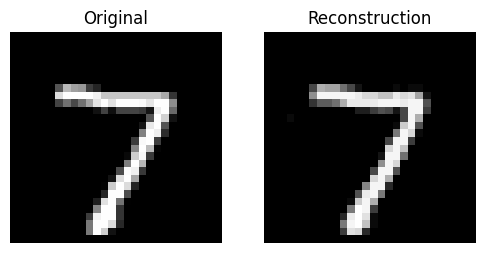

In [10]:
# Visualize original vs reconstructed image

model.eval()
with torch.no_grad():
    x, _ = next(iter(test_loader))
    x = x.view(-1, 784).to(device)

    spk = spikegen.rate(x, num_steps=num_steps)
    spk_out = model(spk)
    recon = spk_out.mean(0)

# Plot one example
plt.figure(figsize=(6,3))

plt.subplot(1,2,1)
plt.imshow(x[0].cpu().view(28,28), cmap="gray")
plt.title("Original")
plt.axis("off")

plt.subplot(1,2,2)
plt.imshow(recon[0].cpu().view(28,28), cmap="gray")
plt.title("Reconstruction")
plt.axis("off")

plt.show()


## ✅ Conclusion

This notebook demonstrates that a spiking neural network can successfully **encode and reconstruct images** using spike-based representations.

Key observations:
- Rate coding effectively converts static inputs into spike trains
- Temporal spike activity can be decoded to recover original signals
- SNNs can perform representation learning similar to traditional neural networks

This serves as a foundation for more advanced spike-based generative models.